**Name:** Husijia Wu  
**Student ID:** 33407088

# Section 1: Model Complexity and Model Selection


In [1]:
from sklearn.base import BaseEstimator
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

## Question 1: KNN Regressor


### Part 1: Implementation Principles of the Weighted K-Nearest Neighbours Regressor



In this part, a K-nearest-neighbours regressor with sample weighting is implemented from scratch. To keep the explanation closely aligned with the code, the underlying principles are presented through the two core methods of the class, `fit` and `predict`.

#### The `fit` Method — Training and Parameter Storage

KNN is a typical **lazy learning** algorithm: during training it simply stores the training features and target values. The only substantive computation at this stage is feature standardisation, which is performed when the `standardise` option is enabled.

In distance-based metrics, features with a larger absolute numeric range dominate the distance computation disproportionately. To remove the bias introduced by differing feature scales, the model applies Z-score standardisation:

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

> *$x_{scaled}$: standardised value; $x$: raw value; $\mu$, $\sigma$: training-set mean and standard deviation.*

Two implementation details matter here:

- **No data leakage.** $\mu$ and $\sigma$ are computed strictly from the **training set only**, and are stored inside the model so that the identical transformation can be reapplied at prediction time.
- **Zero-variance guard.** If a feature has zero variance, its standard deviation is safely set to 1.0 to avoid division by zero.

#### The `predict` Method — Distance Metric and Prediction

Given new data, the model first applies the same standardisation using the $\mu$ and $\sigma$ recorded during `fit`, and then proceeds to distance computation and prediction aggregation.

- **Distance metric.** The model uses the Minkowski distance to measure the similarity between a query point and the training points. By varying the parameter $p$, this metric generalises to different distance types: $p=1$ gives the Manhattan distance and $p=2$ the Euclidean distance.

$$D(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}$$

> *$x$, $y$: two sample points; $n$: feature dimensionality; $x_i$, $y_i$: their $i$-th components; $p$: distance type.*

Once the $k$ nearest neighbours have been identified, the model supports two aggregation rules:

- **Uniform weights.** All selected neighbours receive the same weight, and the prediction is the arithmetic mean of their target values:

$$\hat{y} = \frac{1}{k} \sum_{i=1}^{k} y_i$$

> *$\hat{y}$: prediction; $k$: number of neighbours; $y_i$: target value of neighbour $i$.*

- **Inverse-distance weights.** Closer neighbours contribute more to the prediction, which is computed as a weighted average:

$$w_i = \frac{1}{(d_i + \epsilon)^q} \qquad\qquad \hat{y} = \frac{\sum_{i=1}^{k} w_i \cdot y_i}{\sum_{i=1}^{k} w_i}$$

> *$w_i$, $d_i$: weight and distance of neighbour $i$; $\epsilon$: zero-division guard (`eps`); $q$: weight exponent, controls decay with distance (`weight_power`); $y_i$: its target value.*

- **Zero-distance case.** If one or more of the selected neighbours lie at zero distance from the query point, the prediction is determined **solely** by the mean target value of those zero-distance neighbours, and neighbours with non-zero distance do not contribute. Otherwise, the inverse-distance rule above applies.

In [2]:
class WeightedKnnRegressor(BaseEstimator):
    def __init__(
        self,
        n_neighbors=5,      
        p=2,                
        weights="uniform",  
        weight_power=1.0,   
        standardise=False,  
        eps=1e-8            
    ):
        # Store all instructor-specified parameters above in the model for later use
        self.n_neighbors = n_neighbors
        self.p = p
        self.weights = weights
        self.weight_power = weight_power
        self.standardise = standardise
        self.eps = eps

    def fit(self, X, y):
        # --- Model training phase ---
        # 1. Store all training examples (X) and target values (y) in the model
        self.X_train_ = np.array(X)
        self.y_train_ = np.array(y)
        
        # 2. Feature standardisation
        if self.standardise:
            # Compute the mean and standard deviation of each feature column and save them as self attributes for later use
            self.X_mean_ = np.mean(self.X_train_, axis=0)
            self.X_std_ = np.std(self.X_train_, axis=0)
            
            # If a column is constant, its standard deviation is 0 and division by zero would fail, so replace 0 with 1
            self.X_std_[self.X_std_ == 0] = 1.0
            
            # Convert all data to the same scale: (original value - mean) / standard deviation
            self.X_train_ = (self.X_train_ - self.X_mean_) / self.X_std_
            
        return self

    def predict(self, X):
        # --- Model prediction phase ---
        X_test = np.array(X) # Get the test data to be predicted
        
        # Apply the same scaling using self.X_mean_ and self.X_std_ computed during training
        if self.standardise:
            X_test = (X_test - self.X_mean_) / self.X_std_

        # Prepare an empty array for the final predictions
        predictions = np.zeros(X_test.shape[0])  
            
        
        # Predict the test data one row at a time
        for row_index in range(X_test.shape[0]):

            # 2. Compute distances between the test sample and all stored training samples
            current_test_sample = X_test[row_index] # Extract the current test sample (for example, its 12 features)
            diff = np.abs(self.X_train_ - current_test_sample)
            current_distances = np.sum(diff ** self.p, axis=1) ** (1.0 / self.p)     
            
            # Find the indices of the k nearest neighbours, then obtain their distances and true targets
            nearest_neighbor_indices = np.argsort(current_distances)[:self.n_neighbors]
            nearest_neighbor_distances = current_distances[nearest_neighbor_indices]
            nearest_neighbor_targets = self.y_train_[nearest_neighbor_indices]
            
            # Rule A: take the arithmetic mean directly
            if self.weights == 'uniform':
                predictions[row_index] = np.mean(nearest_neighbor_targets)
                
            # Rule B: weight by distance, giving closer neighbours greater influence
            elif self.weights == 'inverse':
                # If an identical training sample is found (distance 0), use the mean target of those exact matches
                is_distance_zero = (nearest_neighbor_distances == 0)
                
                if np.any(is_distance_zero):
                    predictions[row_index] = np.mean(nearest_neighbor_targets[is_distance_zero])
                else:        
                    neighbor_weights = 1.0 / ((nearest_neighbor_distances + self.eps) ** self.weight_power)   # If there are no zero-distance samples, apply the weighting formula
                    predictions[row_index] = np.average(nearest_neighbor_targets, weights=neighbor_weights)  # Compute the weighted mean using the neighbour weights
                    
        return predictions

### Part 2: Experimental Evaluation

In [3]:
# 1. Load the diabetes dataset (set scaled=False to obtain the original unstandardised data)
X, y = load_diabetes(return_X_y=True, scaled=False)

# 2. Split the data into 70% training and 30% test sets, using random seed 5201 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5201)

# 3. Define the list of neighbour counts (k) to evaluate their effect on KNN performance
k_values = [1, 3, 7, 15, 31]

# 4. Initialise nested dictionaries to record training and test mean squared error (MSE) for configurations A, B, C, and D
results = {
    'A': {'train_mse': [], 'test_mse': []},
    'B': {'train_mse': [], 'test_mse': []},
    'C': {'train_mse': [], 'test_mse': []},
    'D': {'train_mse': [], 'test_mse': []}
}

In [4]:
# 1. Define the four hyperparameter configurations (A/B/C/D specify weighting, power, and feature standardisation)
configs = {
    'A': {'weights': 'uniform', 'weight_power': 1.0, 'standardise': False},
    'B': {'weights': 'inverse', 'weight_power': 1.0, 'standardise': False},
    'C': {'weights': 'inverse', 'weight_power': 1.0, 'standardise': True},
    'D': {'weights': 'inverse', 'weight_power': 2.0, 'standardise': True}
}

# 2. Run nested loops to train and evaluate the models
# Outer loop: iterate over the four model configurations A, B, C, and D
for config_name, config_params in configs.items():
    
    # Inner loop: iterate over the candidate neighbour counts (k) for the current configuration
    for k in k_values:
        # Instantiate the KNN regressor using the current parameters
        model = WeightedKnnRegressor(
            n_neighbors=k,
            p=2, 
            weights=config_params['weights'],
            weight_power=config_params['weight_power'],
            standardise=config_params['standardise']
        )
        
        # Fit the model on the training set
        model.fit(X_train, y_train)
        
        # Generate predictions for the training and test sets
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Compute mean squared error (MSE) for the training and test sets
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        # Append the computed MSE values to the corresponding lists in the results dictionary
        results[config_name]['train_mse'].append(train_mse)
        results[config_name]['test_mse'].append(test_mse)


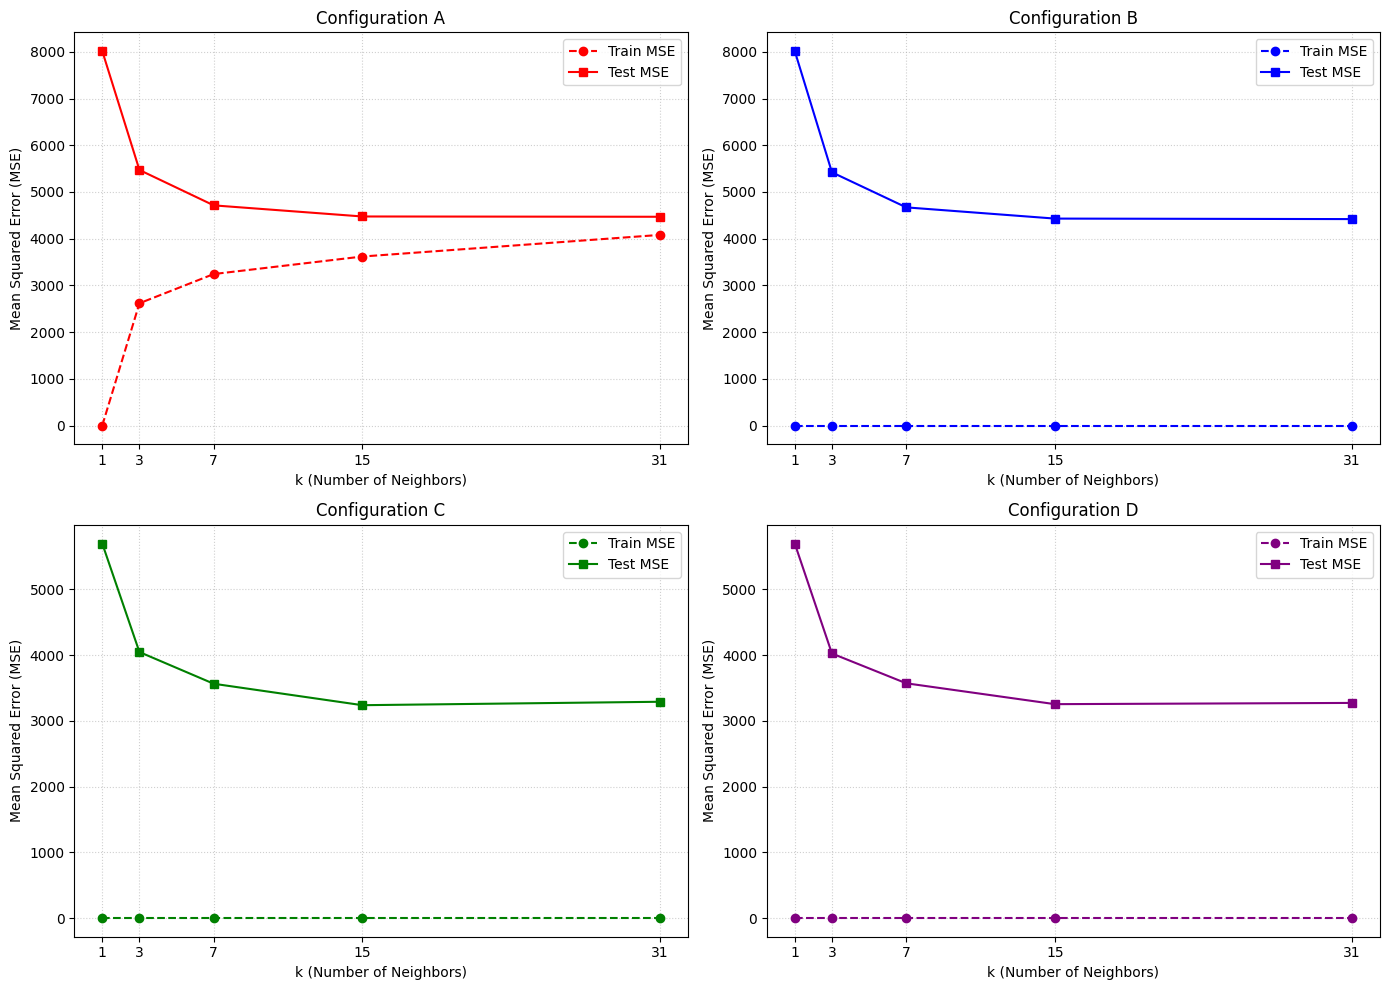

In [5]:

# Create a large 2x2 figure with one panel for each configuration
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'A': 'red', 'B': 'blue', 'C': 'green', 'D': 'purple'}
k_values = [1, 3, 7, 15, 31]

# Plot a performance curve for each model configuration
for idx, config in enumerate(['A', 'B', 'C', 'D']):
    ax = axes[idx]
    
    # Plot training-set performance with a dashed line
    ax.plot(k_values, results[config]['train_mse'], 
            marker='o', linestyle='--', color=colors[config], label='Train MSE')
    
    # Plot test-set performance with a solid line
    ax.plot(k_values, results[config]['test_mse'], 
            marker='s', linestyle='-', color=colors[config], label='Test MSE')
    
    ax.set_title(f'Configuration {config}')
    ax.set_xlabel('k (Number of Neighbors)')
    ax.set_ylabel('Mean Squared Error (MSE)')
    ax.set_xticks(k_values)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()

#### Discussion (Word count: ~185 words)

At $k=1$, training MSE is 0 for every configuration, while test MSE is 8017.29 for A and B and 5695.17 for C and D, showing severe overfitting. As $k$ increases, Configuration A’s training MSE rises to 4080.35 at $k=31$ because uniform weighting averages increasingly distant neighbours. In contrast, the training MSEs of B, C, and D remain 0 because an exact zero-distance neighbour determines every training prediction.

Test MSE initially decreases as $k$ increases. However, mild underfitting appears at larger $k$: C increases from 3236.65 at $k=15$ to 3288.82 at $k=31$, while D increases from 3252.50 to 3271.30.

Comparing B and C demonstrates the importance of standardisation. At $k=15$, standardisation reduces test MSE from 4430.20 in B to 3236.65 in C because it prevents features with larger numerical scales from dominating the distance.

Increasing `weight_power` from 1 in C to 2 in D gives closer neighbours greater influence. Nevertheless, their test performance is similar: at $k=31$, their MSEs are 3288.82 and 3271.30, respectively. Thus, the stronger distance weighting provides only a small improvement for this dataset.

## Question 2: L-Fold Cross-Validation


### Part 1: Blocked L-Fold Cross-Validation

In [6]:
class BlockedLFold:
    def __init__(self, n_splits=7, gap=5):
        # Store the specified number of splits and gap size
        self.n_splits = n_splits   
        self.gap = gap

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits   # Simply return the stored number of splits when requested

    def split(self, X, y=None, groups=None):
        number = len(X)     # Assume 10 observations, 3 folds, and gap = 1; therefore number = 10
        indices = np.arange(number)    # Assign indices to the observations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
        
        # 1. Divide the observations into n_splits contiguous folds. Since 10 divided by 3 leaves 1, the extra observation goes to the first fold. fold_indices now contains three folds:
        # First: [0, 1, 2, 3], second: [4, 5, 6], third: [7, 8, 9]
        fold_indices = np.array_split(indices, self.n_splits)
        
        # Process the folds one at a time
        for test_idx in fold_indices: # Use the second fold as an example, so test_idx = [4, 5, 6]
            if len(test_idx) == 0:   # Skip an empty test fold
                continue
                
            # Find the indices of the first (a) and last (b) observations in this test fold
            first_data = test_idx[0]  # a = 4
            last_data = test_idx[-1] # b = 6
            
            # 2. Core rule: create a buffer to prevent leakage. Exclude the gap observations before and after the test fold; this example assumes gap=1
            exclude_start = first_data - self.gap # exclude_start = 4 - 1 = 3 (observation 3 is excluded)
            exclude_end = last_data + self.gap   # exclude_end = 6 + 1 = 7 (observation 7 is excluded)
            
            # 3. An observation can be used for training only if its index lies before or after the exclusion interval
            train_mask = (indices < exclude_start) | (indices > exclude_end)    # The condition requires an index < 3 or > 7, selecting eligible values from [0,1,2,3,4,5,6,7,8,9]
            
            # The final training indices are [0, 1, 2, 8, 9]
            train_idx = indices[train_mask]
            
            # Yield the training indices (train_idx) and test indices (test_idx)
            yield train_idx, test_idx

### Part 2: Model Selection and Uncertainty Estimation

In [7]:
# ==========================================================
# Module 1: Prepare the data and validation setup
# ==========================================================
# 1. Load the complete dataset; X contains the patients' physical measurements (features)
X, y = load_diabetes(return_X_y=True, scaled=False)

# 2. Prepare candidate neighbour counts k, giving k_candidates = [1, 3, 5, 7, ..., 57, 59]
k_candidates = np.arange(1, 60, 2)
results_list = []

# 3. Initialise the Blocked L-Fold splitter (7 folds, gap of 5)
cv = BlockedLFold(n_splits=7, gap=5)

np.random.seed(5201)   # Set the specified random seed so every random draw is reproducible


# ==========================================================
# Module 2: Model training and 7-fold cross-validation
# ==========================================================
for k in k_candidates:
    # Initialise the weighted KNN model using the required configuration
    model = WeightedKnnRegressor(
        n_neighbors=k, p=2, weights="inverse",
        weight_power=1, standardise=True
    )
    
    # Prepare a list to store the seven observed fold scores
    fold_mses = []
    
    # Run the seven train/test splits
    for train_idx, test_idx in cv.split(X):
        X_train_fold, y_train_fold = X[train_idx], y[train_idx]
        X_test_fold, y_test_fold = X[test_idx], y[test_idx]

        # Fit the model and generate predictions
        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_test_fold)
        
        # Compute the MSE and append it to the list
        fold_mses.append(mean_squared_error(y_test_fold, preds))
        
    # For illustration, suppose the seven observed MSE scores are [3000, 3100, 2900, 3200, 3050, 2950, 3150]
    fold_mses = np.array(fold_mses)
    
    
    # ==========================================================
    # Module 3: Uncertainty estimation (Student-t and bootstrap); the bootstrap sampling pool is the seven observed MSE scores in fold_mses
    # ==========================================================
    # ------------------ Observed values ------------------
    # 1. Compute the mean of the seven observed fold scores (for example, the seven values above average to 3050)
    mean_mse = np.mean(fold_mses)
    std_dev = np.std(fold_mses, ddof=1)      # Compute the variation in the observed scores (standard deviation)
    std_error = std_dev / np.sqrt(7)         # Standard error of the mean (SEM): how uncertain the seven-fold mean is as an estimate of true performance
    
    # 2. Student-t 95% confidence interval (formula/table method)
    t_value = stats.t.ppf(0.975, df=6)    # Upper quantile: 95% + 2.5% = 97.5%
    t_lower = mean_mse - t_value * std_error
    t_upper = mean_mse + t_value * std_error


    # ------------------ Resampled values ------------------
    # 3. Bootstrap 95% confidence interval (resampling method)
    boot_means = [] # Empty list for 2,000 bootstrap means: []
    
    # Repeat the bootstrap sampling procedure 2,000 times
    for _ in range(2000):
        # Draw 7 values with replacement from [3000, 3100, 2900, 3200, 3050, 2950, 3150]
        # For example, the first boot_sample might be [3000, 3000, 3200, 2900, 3150, 3150, 2950]
        boot_sample = np.random.choice(fold_mses, size=7, replace=True)
        
        # Compute the mean of this bootstrap sample and append it to the list
        # After iteration 1, boot_means might be [3050]; after iteration 2, [3050, 3110]; continue until it contains 2,000 values
        boot_means.append(np.mean(boot_sample))
        
    # Sort the 2,000 bootstrap means from smallest to largest, for example [2900, 2910, ..., 3180, 3200]
    # Use the 2.5th percentile as the lower bound (discarding the lowest 50 extreme values)
    boot_lower = np.percentile(boot_means, 2.5)
    # Use the 97.5th percentile as the upper bound (discarding the highest 50 extreme values)
    boot_upper = np.percentile(boot_means, 97.5)
    
    
    # ==========================================================
    # Module 4: Save the results
    # ==========================================================
    results_list.append({
        'k': k,
        'Mean MSE': mean_mse,
        'SE': std_error,
        't-Lower': t_lower,
        't-Upper': t_upper,
        'Boot-Lower': boot_lower,
        'Boot-Upper': boot_upper
    })

# Display the records as a well-formatted table
df_results = pd.DataFrame(results_list)
display(df_results)

,k,Mean MSE,SE,t-Lower,t-Upper,Boot-Lower,Boot-Upper
0,1,5381.575503,345.340933,4536.556683,6226.594324,4803.634460,6032.551020
1,3,3874.407569,242.843818,3280.190152,4468.624986,3431.661496,4305.832623
2,5,3677.032766,222.302968,3133.077000,4220.988532,3312.900158,4070.643580
3,7,3571.033818,175.797096,3140.873819,4001.193817,3250.628217,3883.600025
4,9,3462.687183,203.002922,2965.956928,3959.417437,3108.659700,3831.980563
5,11,3353.819506,219.216522,2817.416002,3890.223011,2965.549166,3740.024451
6,13,3326.782798,201.508013,2833.710454,3819.855142,2962.744852,3702.491030
7,15,3289.230111,182.407488,2842.895066,3735.565156,2940.755174,3603.717264
8,17,3257.843458,169.938898,2842.017954,3673.668961,2935.168543,3561.801685
9,19,3262.209328,171.279348,2843.103860,3681.314795,2945.886640,3556.743596


In [8]:
# ==========================================================
# Module 5: Select the optimal neighbour count k using two selection rules
# ==========================================================
# Observed result: the current minimum error occurs at k=25, with MSE 3229.13 and SE 130.23

# ----------------------------------------------------------
# Method 1: Minimum-MSE rule (select the k with the smallest absolute error)
# ----------------------------------------------------------
# Locate the row with the minimum 'Mean MSE'; if tied, choose the row with the largest k
min_mse_row = df_results[df_results['Mean MSE'] == df_results['Mean MSE'].min()].sort_values('k').iloc[-1]

# Extract the metrics from this row
k_min = int(min_mse_row['k'])        # k with the minimum error (25 in the observed results)
mse_min = min_mse_row['Mean MSE']    # Minimum mean error (3229.13 in the observed results)
se_min = min_mse_row['SE']           # Corresponding standard error (130.23 in the observed results)

print(f"Rule 1 (Minimum-MSE): Optimal k = {k_min} (Lowest MSE = {mse_min:.2f})")


# ----------------------------------------------------------
# Method 2: One-Standard-Error (1-SE) rule (select the most robust k within the acceptable error range)
# ----------------------------------------------------------
# Compute the threshold as the minimum error plus its standard error (for example, 3229.13 + 130.23 = 3359.36), allowing some error variation in exchange for stability
threshold = mse_min + se_min
print(f"Threshold for 1-SE rule: {threshold:.2f}")

# Keep all candidate rows whose 'Mean MSE' is less than or equal to the threshold
qualified_candidates_df = df_results[df_results['Mean MSE'] <= threshold]    # Eligible values include k=11 (MSE 3353.82), k=25 (MSE 3229.13), k=29 (MSE 3273.08), and values through k=59

# Among all candidates meeting the error criterion, choose the largest k
# In KNN, a larger k produces a smoother decision boundary and greater tolerance to noise, making the model more robust; the largest eligible value here is 59
optimal_robust_k = int(qualified_candidates_df['k'].max())

print(f"Rule 2 (One-Standard-Error): Optimal k = {optimal_robust_k}")

Rule 1 (Minimum-MSE): Optimal k = 25 (Lowest MSE = 3229.13)
Threshold for 1-SE rule: 3359.36
Rule 2 (One-Standard-Error): Optimal k = 59


####  Question 2 Part 2 — Discussion

Mean test MSE falls sharply from 5381.58 at (k=1) to its minimum of 3229.13 at (k=25), after which it remains relatively flat; for example, it is 3290.87 at (k=33) and 3344.53 at (k=59). The substantial overlap among the confidence intervals therefore suggests a range of similarly performing values rather than one clearly superior (k).

The minimum-MSE rule selects (k=25). Its SE is 130.23, giving a one-standard-error threshold of 3359.36. Every candidate from (k=11) through (k=59) satisfies this threshold, so the one-standard-error rule selects (k=59).

At (k=25), the Student-(t) interval is [2910.46, 3547.80], with width 637.34, whereas the bootstrap interval is [2984.15, 3444.86], with width 460.71. The Student-(t) interval is symmetric by construction, while the percentile bootstrap interval is narrower and mildly asymmetric. Incorporating uncertainty therefore changes the decision from the raw optimum (k=25) to the smoother (k=59), whose MSE is only 115.40 higher.

### Part 3: Sensitivity to the Gap Size

In [9]:
# Part 3: Explore how the gap size affects model performance

# 1. Prepare the complete dataset and the candidate k values
X, y = load_diabetes(return_X_y=True, scaled=False)
k_candidates = np.arange(1, 60, 2)          # Generate k_candidates = [1, 3, 5, 7, ..., 57, 59]

gap_test_sizes = [0, 5, 15]   # The three required gap sizes
final_summary_report = []    # Prepare a final summary table for the reports from the three gap values

# ==========================================================
# Outer loop: test gap=0, gap=5, and gap=15
# ==========================================================
for current_gap in gap_test_sizes:
    
    # Configure the splitter for the current gap size
    cv = BlockedLFold(n_splits=7, gap=current_gap)
    
    # Prepare four lists for the detailed results at the current gap
    training_sample_counts = []  # Record training-set sizes for the required minimum, maximum, and mean
    t_bounds_widths = []         # Record the widths of the Student-t confidence intervals
    boot_bounds_widths = []      # Record the widths of the bootstrap confidence intervals
    current_gap_results = []     # Record the result for each k value
    
    # ==========================================================
    # Inner loop: evaluate every candidate k across seven folds, as above
    # ==========================================================
    for k in k_candidates:
        model = WeightedKnnRegressor(
            n_neighbors=k, p=2, weights="inverse",
            weight_power=1, standardise=True
        )
        
        fold_mses = []
        
        for train_idx, test_idx in cv.split(X):
            # For k=1 only, record the training-set size in each fold because the splits do not depend on k and need to be counted only once
            if k == 1:
                training_sample_counts.append(len(train_idx))
                
            X_train_fold, y_train_fold = X[train_idx], y[train_idx]
            X_test_fold, y_test_fold = X[test_idx], y[test_idx]
            
            model.fit(X_train_fold, y_train_fold)
            preds = model.predict(X_test_fold)
            fold_mses.append(mean_squared_error(y_test_fold, preds))
            
        fold_mses = np.array(fold_mses)   # The seven observed mean squared error (MSE) values
        
        # Compute the mean and standard error (SE)
        mean_mse = np.mean(fold_mses)
        std_dev = np.std(fold_mses, ddof=1)   # When sample variation is used to estimate population variation, dividing directly by N tends to underestimate it, producing a biased estimate
        std_error = std_dev / np.sqrt(7)    # Compute the standard error (SE) as the standard deviation divided by sqrt(7); smaller values indicate a more reliable mean estimate
        
        # ----- Compute the Student-t interval bounds and record the width (upper minus lower) -----
        t_value = stats.t.ppf(0.975, df=6)     # Look up the Student-t quantile; with L=7 folds, the degrees of freedom are L-1=6
        t_lower = mean_mse - t_value * std_error
        t_upper = mean_mse + t_value * std_error
        t_bounds_widths.append(t_upper - t_lower)
        
        # ----- Compute the bootstrap interval bounds and record the width -----
        np.random.seed(5201)
        boot_means = []   # Empty list for 2,000 bootstrap means: []
        for _ in range(2000):
            boot_sample = np.random.choice(fold_mses, size=7, replace=True)
            boot_means.append(np.mean(boot_sample))
            
        boot_lower = np.percentile(boot_means, 2.5)
        boot_upper = np.percentile(boot_means, 97.5)
        boot_bounds_widths.append(boot_upper - boot_lower)
        
        # Store the results for this k
        current_gap_results.append({
            'k': k,
            'Mean MSE': mean_mse,
            'SE': std_error
        })
        
    # Convert all results for the current gap to a DataFrame
    df_current_results = pd.DataFrame(current_gap_results)
    
    # ==========================================================
    # Select the two preferred k values for the current gap
    # ==========================================================
    # Selection rule 1: Minimum-MSE (best absolute score)
    min_mse_row = df_current_results[df_current_results['Mean MSE'] == df_current_results['Mean MSE'].min()].sort_values('k').iloc[-1]
    k_min = int(min_mse_row['k'])
    min_mse = min_mse_row['Mean MSE']
    se_min = min_mse_row['SE']
    
    # Selection rule 2: One-standard-error (most robust candidate)
    threshold = min_mse + se_min
    qualified_candidates = df_current_results[df_current_results['Mean MSE'] <= threshold]   # Extract the candidates that meet the criterion
    optimal_robust_k = int(qualified_candidates['k'].max())
    
    # ==========================================================
    # Package the five required metrics and add them to the summary table
    # ==========================================================
    final_summary_report.append({
        'Gap Size': current_gap,
        'Selected k (Min-MSE)': k_min,
        'Selected k (1-SE)': optimal_robust_k,
        'Train Size (Min)': np.min(training_sample_counts),
        'Train Size (Max)': np.max(training_sample_counts),
        'Train Size (Mean)': np.mean(training_sample_counts),
        'Avg t-Interval Width': np.mean(t_bounds_widths),
        'Avg Boot-Interval Width': np.mean(boot_bounds_widths)
    })

# Display the final summary table
df_final_report = pd.DataFrame(final_summary_report)
display(df_final_report)

,Gap Size,Selected k (Min-MSE),Selected k (1-SE),Train Size (Min),Train Size (Max),Train Size (Mean),Avg t-Interval Width,Avg Boot-Interval Width
0,0,25,59,378,379,378.857143,672.357957,477.790842
1,5,25,59,369,374,370.285714,666.685947,474.730959
2,15,23,59,349,364,353.142857,686.551761,489.517490


#### Question 2 Part 3 — Discussion

All three mean test-MSE curves have a similar shape: a sharp improvement for small (k), a broad minimum in the low-to-mid twenties, and gradual deterioration at larger (k). For (g=0), MSE decreases from 5401.74 at (k=1) to 3233.38 at (k=25), then reaches 3344.31 at (k=59). The corresponding values for (g=5) are 5381.58, 3229.13, and 3344.53. With (g=15), the minimum shifts slightly to (k=23), with MSE 3222.34, while the values at (k=1) and (59) are 5522.23 and 3351.83. Thus, the minimum-MSE selection changes only from 25 to 23, while the one-standard-error rule selects (k=59) for every gap.

Increasing the gap reduces the effective training size. The mean training size falls from 378.86 for (g=0), to 370.29 for (g=5), and 353.14 for (g=15). Interval widths change only modestly: average Student-(t) widths are 672.36, 666.69, and 686.55, while bootstrap widths are 477.79, 474.73, and 489.52. A larger gap provides stronger separation between training and test observations, but leaves fewer training examples and slightly increases uncertainty at (g=15).

## Question 3 ：Automatic Model Selection with Nested Cross-Validation

### Part 1: Weighted KNN with Internal Cross-Validation

#### Conceptual Explanation

Standardisation must be fitted separately within each internal training fold. Calculating the mean and standard deviation using the validation fold would leak validation information into model fitting and could bias the validation MSE downward.

Using the same observations for hyperparameter selection and final performance evaluation is optimistic because (k) is selected partly according to random favourable variation in those observations. An independent outer test fold is therefore required to evaluate the complete selection procedure.

The one-standard-error rule accepts candidates whose mean validation MSE is statistically close to the minimum and then chooses the largest eligible (k). A larger (k) averages more neighbours, producing a smoother regression function with lower variance. Consequently, the rule favours a smoother model unless the evidence supporting a smaller (k) is sufficiently strong.

In [10]:
from sklearn.base import BaseEstimator
# ==========================================================
# Module 1: Main weighted KNN regressor class with internal cross-validation
# ==========================================================
class WeightedKnnRegressorCV(BaseEstimator):
    def __init__(
        self,
        ks=None,
        cv=None,
        selection_rule="minimum"
    ):
        self.ks = ks if ks is not None else np.arange(1, 60, 2)    # If not supplied, use odd integers from 1 to 59 as the candidate k values
        self.cv = cv if cv is not None else BlockedLFold(n_splits=6, gap=5)    # By default, use a 6-fold splitter with gap=5 for internal validation
        self.selection_rule = selection_rule  
        
    def fit(self, X, y):
        # X and y are the six training folds passed in after the outer splitter holds out one fold for final testing
        X_arr = np.array(X)      # Receive the six outer-training folds of features and convert them to an array for internal splitting
        y_arr = np.array(y)      # Receive the corresponding target values and convert them to an array
        
        # Prepare two lists to record the final mean performance and uncertainty for every candidate k
        candidate_mean_mses = []
        candidate_standard_errors = []
        
        # ==========================================================
        # Module 2: Internal cross-validation and scoring (validation stage)
        # ==========================================================
        for k in self.ks:
            fold_validation_mses = []    # Prepare a list to record the current candidate k's scores on the six validation folds

            # Internal validation loop: assign a training set and a validation set
            for train_idx, val_idx in self.cv.split(X_arr):
                X_train_fold, y_train_fold = X_arr[train_idx], y_arr[train_idx]
                X_val_fold, y_val_fold = X_arr[val_idx], y_arr[val_idx]
                
                # Initialise the base weighted KNN model as required
                model = WeightedKnnRegressor(
                    n_neighbors=k, p=2, weights="inverse",  # Distance weighting
                    weight_power=1, standardise=True   # Each internal split must be standardised independently
                )
                
                # Fit on the training set and evaluate on the validation set
                model.fit(X_train_fold, y_train_fold)
                preds = model.predict(X_val_fold)
                
                # Record the MSE for the current fold
                fold_validation_mses.append(mean_squared_error(y_val_fold, preds))    
                
            fold_validation_mses = np.array(fold_validation_mses)  # At this point, all six validation folds for the current k are complete
            
            # Compute the mean MSE and standard error (SE) for the current k across the six validation folds
            current_mean_mse = np.mean(fold_validation_mses)                 # Compute mean performance (Mean MSE)
            current_std_dev = np.std(fold_validation_mses, ddof=1)           # Compute score variability (sample standard deviation, requiring ddof=1)
            current_std_error = current_std_dev / np.sqrt(len(fold_validation_mses))     # Compute uncertainty in the mean (standard error: divide by the square root of the number of folds)
            
            # Store the computed results in the overall record
            candidate_mean_mses.append(current_mean_mse)
            candidate_standard_errors.append(current_std_error)

        candidate_mean_mses = np.array(candidate_mean_mses)     # With 30 candidate k values, candidate_mean_mses contains exactly 30 mean scores
        candidate_standard_errors = np.array(candidate_standard_errors)    
        
        # ==========================================================
        # Module 3: Select the optimal hyperparameter k (decision stage)
        # ==========================================================
        if self.selection_rule == "minimum":
            # Rule 1: Minimum-MSE (select the k with the lowest mean squared error)
            absolute_min_mse = np.min(candidate_mean_mses)
            tied_best_indices = np.where(candidate_mean_mses == absolute_min_mse)[0]     # Extract the indices for which the comparison above is True
            # If there is a tie, choose the largest index, corresponding to the largest k and a more robust model
            optimal_k_index = tied_best_indices[-1] 
            
        elif self.selection_rule == "one_se": 
            # Rule 2: One-Standard-Error (1-SE rule)
            absolute_min_index = np.argmin(candidate_mean_mses)                      # Locate the candidate with the absolute minimum Mean MSE and obtain its index in the results
            absolute_min_mse = candidate_mean_mses[absolute_min_index]               # Extract that candidate's mean score as the baseline for the 1-SE tolerance threshold
            corresponding_se = candidate_standard_errors[absolute_min_index]         # Extract the corresponding standard error (SE) to relax the final selection threshold
            
            # Set the threshold to the minimum mean score plus its corresponding standard error
            tolerance_threshold = absolute_min_mse + corresponding_se
            
            qualified_indices = np.where(candidate_mean_mses <= tolerance_threshold)[0]     # Select all candidates with MSE less than or equal to the threshold and extract their indices
            optimal_k_index = qualified_indices[-1]    # Among all eligible candidates, choose the largest index, corresponding to the largest k
            
        else:
            raise ValueError("Invalid selection_rule. Supported values are 'minimum' and 'one_se'.")
            
        # Save the selection results for final output or use by the outer code
        self.best_k_ = self.ks[optimal_k_index]
        self.mean_inner_validation_mse_ = candidate_mean_mses[optimal_k_index]
        
        # ==========================================================
        # Module 4: Fit the final model (deployment stage)
        # ==========================================================
        # Retrain the final model using the selected k and all available data (X_arr, y_arr)
        self.best_model_ = WeightedKnnRegressor(
            n_neighbors=self.best_k_, p=2, weights="inverse",
            weight_power=1, standardise=True
        )
        self.best_model_.fit(X_arr, y_arr)
        
        return self
        
    def predict(self, X):
        # For prediction, call the final model fitted in Module 4
        return self.best_model_.predict(X)

### Part 2: Nested Blocked Cross-Validation

In [11]:
# Part 2: Nested blocked cross-validation
# Load the dataset
X, y = load_diabetes(return_X_y=True, scaled=False)

# ==========================================================
# Define the data splitters
# ==========================================================
outer_cv = BlockedLFold(n_splits=5, gap=5)    # Outer CV: split the data into five folds, using four for training and one for final testing
inner_cv = BlockedLFold(n_splits=6, gap=5)    # Inner CV: use six folds inside the automated model to select the hyperparameter

nested_results = []    # Prepare an overall results list for the key values from each completed outer fold

# ==========================================================
# Outer loop: final testing stage, simulating unseen real-world data
# ==========================================================
for outer_fold_idx, (outer_train_idx, outer_test_idx) in enumerate(outer_cv.split(X)):
    
    # 1. Isolate the outer test set by holding out this fold for final evaluation
    X_outer_train, y_outer_train = X[outer_train_idx], y[outer_train_idx]
    X_outer_test, y_outer_test = X[outer_test_idx], y[outer_test_idx]
    
    # Run both selection rules separately within every outer fold
    for rule in ["minimum", "one_se"]: 
        
        # ==========================================================
        # Inner loop: automatic hyperparameter selection (validation stage)
        # ==========================================================
        # Initialise the automated model defined above
        auto_knn_cv = WeightedKnnRegressorCV(
            ks=np.arange(1, 60, 2),
            cv=inner_cv,  # Pass the six-fold inner splitter to the model so it can split X_outer_train internally
            selection_rule=rule
        )
        
        # Start the model using only the outer training data; it performs internal validation, selects the best k, and fits the final model
        auto_knn_cv.fit(X_outer_train, y_outer_train)
        
        # ==========================================================
        # Final evaluation: reveal the held-out test set
        # ==========================================================
        # Use the selected final model to predict the completely unseen test observations
        test_predictions = auto_knn_cv.predict(X_outer_test)
        
        test_mse = mean_squared_error(y_outer_test, test_predictions)     # Evaluate the final test predictions using mean squared error (MSE)
        
        # Compute optimism gap as observed test error minus expected internal-validation error; a positive value indicates overly optimistic internal selection
        optimism_gap = test_mse - auto_knn_cv.mean_inner_validation_mse_
        
        # Record this round's scores and configuration in the overall results
        nested_results.append({
            'Outer Fold': outer_fold_idx + 1,
            'Rule': rule,
            'Selected k': auto_knn_cv.best_k_,
            'Inner Val MSE': auto_knn_cv.mean_inner_validation_mse_,
            'Outer Test MSE': test_mse,
            'Optimism Gap': optimism_gap
        })

# Display the final performance report
df_nested = pd.DataFrame(nested_results)
display(df_nested)

,Outer Fold,Rule,Selected k,Inner Val MSE,Outer Test MSE,Optimism Gap
0,1,minimum,17,3208.962367,3275.541163,66.578796
1,1,one_se,55,3318.809163,3328.085105,9.275942
2,2,minimum,17,3357.828085,3213.400991,-144.427094
3,2,one_se,59,3495.585409,3424.245949,-71.339460
4,3,minimum,19,3332.378671,3455.857534,123.478862
5,3,one_se,59,3503.789867,3466.487189,-37.302678
6,4,minimum,17,3393.253035,2835.552452,-557.700582
7,4,one_se,59,3541.201799,2841.110320,-700.091479
8,5,minimum,15,3367.197118,3178.097629,-189.099489
9,5,one_se,59,3480.279154,3553.748534,73.469380


#### Question 3 Part 2 — Discussion

The minimum-MSE rule selects (k=[17,17,19,17,15]), so its choices are relatively stable within the range 15–19. The one-standard-error rule selects (k=[55,59,59,59,59]), consistently choosing a much larger and smoother model.

Mean outer-test MSE is 3191.69 for the minimum rule and 3322.74 for the one-standard-error rule, a difference of 131.05. However, the fold-level penalty for the one-standard-error rule ranges from only 5.56 to 375.65. Therefore, the minimum rule performs better on average, although the difference is small in several folds and is not uniform across the dataset.

The optimism gaps are not generally positive. For the minimum rule they are 66.58, −144.43, 123.48, −557.70, and −189.10, with mean −140.23. For the one-standard-error rule, the mean gap is −145.20 and only two of five folds have positive gaps. Thus, inner-validation MSE is more often higher than outer-test MSE in this experiment, rather than optimistic. This variation reflects the small number of blocked folds and differences in difficulty between contiguous regions, illustrating why inner-validation scores should not replace independent outer evaluation.